In [1]:
import os
import utils.dataset_preprocessing as dprepro
import utils.image_display as imd

import glob
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing as mp
import ants
from joblib import Parallel, delayed

In [2]:
ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

## T1 MNI Template

In [3]:
template_path = os.path.join(ROOT_DIR, "datasets/mni_icbm152_nlin_sym_09a/template_t1_128.nii.gz")

In [ ]:
imd.show_single_nifti(template_path)

## IXI
Original Size: (256, 256, 130)\
1. Resample it to 1mm3
2. Perform bias correction
3. Register to 128x128x128 template

In [ ]:
ixi_t1_unprocessed_folder = ROOT_DIR+"datasets/final_t1_dataset_small/ixi_skullstrip"
ixi_t1_bias_corrected_folder = ROOT_DIR+"datasets/final_t1_dataset_small/ixi_bias_corrected/"
ixi_t1_final_output_folder_registered = ROOT_DIR+"datasets/final_t1_dataset_small/ixi_registered/"

os.makedirs(ixi_t1_bias_corrected_folder, exist_ok=True)
os.makedirs(ixi_t1_final_output_folder_registered, exist_ok=True)

In [ ]:
imd.show_first_4_nifti(ixi_t1_unprocessed_folder)

In [ ]:


def apply_bias_correction(img_file, output_folder):
    output_filepath = os.path.join(output_folder, os.path.basename(img_file))
    
    if not os.path.isfile(output_filepath):
        # Read the image
        input_image = sitk.ReadImage(img_file, sitk.sitkFloat32)
        
        # Apply N4 bias field correction
        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        output_image = corrector.Execute(input_image)
        
        # Save the corrected image
        sitk.WriteImage(output_image, output_filepath)
        return f"Processed {os.path.basename(img_file)}"
    else:
        return f"Skipped {os.path.basename(img_file)}, already processed"

# Get all NIfTI files from the unprocessed folder
ixi_files = sorted(glob.glob(os.path.join(ixi_t1_unprocessed_folder, "*.nii*")))

# Run in parallel (n_jobs=-1 uses all available cores)
results = Parallel(n_jobs=16)(
    delayed(apply_bias_correction)(img_file, ixi_t1_bias_corrected_folder) 
    for img_file in tqdm(ixi_files)
)

In [ ]:
imd.show_first_4_nifti(ixi_t1_bias_corrected_folder)

Resample the images to 1mm3

In [ ]:
ixi_t1_resampled_folder = ROOT_DIR+"datasets/final_t1_dataset_small/ixi_resampled/"
os.makedirs(ixi_t1_resampled_folder, exist_ok=True)

In [ ]:
dprepro.resample_nifti_files_folder_multithreaded(ixi_t1_bias_corrected_folder, ixi_t1_resampled_folder, out_spacing=(1.0, 1.0, 1.0), max_workers=16)


In [ ]:
imd.show_first_4_nifti(ixi_t1_resampled_folder)

In [ ]:
for image_path in tqdm(glob.glob(os.path.join(ixi_t1_resampled_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    oriented_image = sitk.DICOMOrient(itk_image, 'RAS')
    sitk.WriteImage(oriented_image, image_path)

In [ ]:
imd.show_first_4_nifti(ixi_t1_resampled_folder)

In [ ]:
dprepro.register_nifti_files_folder_multithreaded(template_path, ixi_t1_resampled_folder, ixi_t1_final_output_folder_registered, max_workers=16)

In [ ]:
imd.show_first_4_nifti(ixi_t1_final_output_folder_registered)

## OASIS

In [7]:
oasis_t1_skullstrip_bias_corr = ROOT_DIR+"datasets/final_t1_dataset_small/oasis_t1_skullstrip_bias_correction/"

oasis_t1_resampled_folder = ROOT_DIR+"datasets/final_t1_dataset_small/oasis_resampled/"
os.makedirs(oasis_t1_resampled_folder, exist_ok=True)

oasis_t1_reoriented_folder = ROOT_DIR+"datasets/final_t1_dataset_small/oasis_reoriented/"
os.makedirs(oasis_t1_reoriented_folder, exist_ok=True)

oasis_t1_registered_folder = ROOT_DIR+"datasets/final_t1_dataset_small/oasis_registered/"
os.makedirs(oasis_t1_registered_folder, exist_ok=True)


In [ ]:
imd.show_first_4_nifti(oasis_t1_skullstrip_bias_corr)

In [ ]:
dprepro.resample_nifti_files_folder_multithreaded(oasis_t1_skullstrip_bias_corr, oasis_t1_resampled_folder, out_spacing=(1.0, 1.0, 1.0), max_workers=32)

In [ ]:
imd.show_first_4_nifti(oasis_t1_resampled_folder)

In [ ]:
dprepro.reorient_nifti_files_folder_multiprocessing(oasis_t1_resampled_folder, oasis_t1_reoriented_folder, max_workers=32)

In [ ]:
imd.show_first_4_nifti(oasis_t1_reoriented_folder)

In [8]:
dprepro.register_nifti_files_folder_multithreaded(template_path, oasis_t1_reoriented_folder, oasis_t1_registered_folder, max_workers=32)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2357/2357 [5:31:49<00:00,  8.45s/it]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

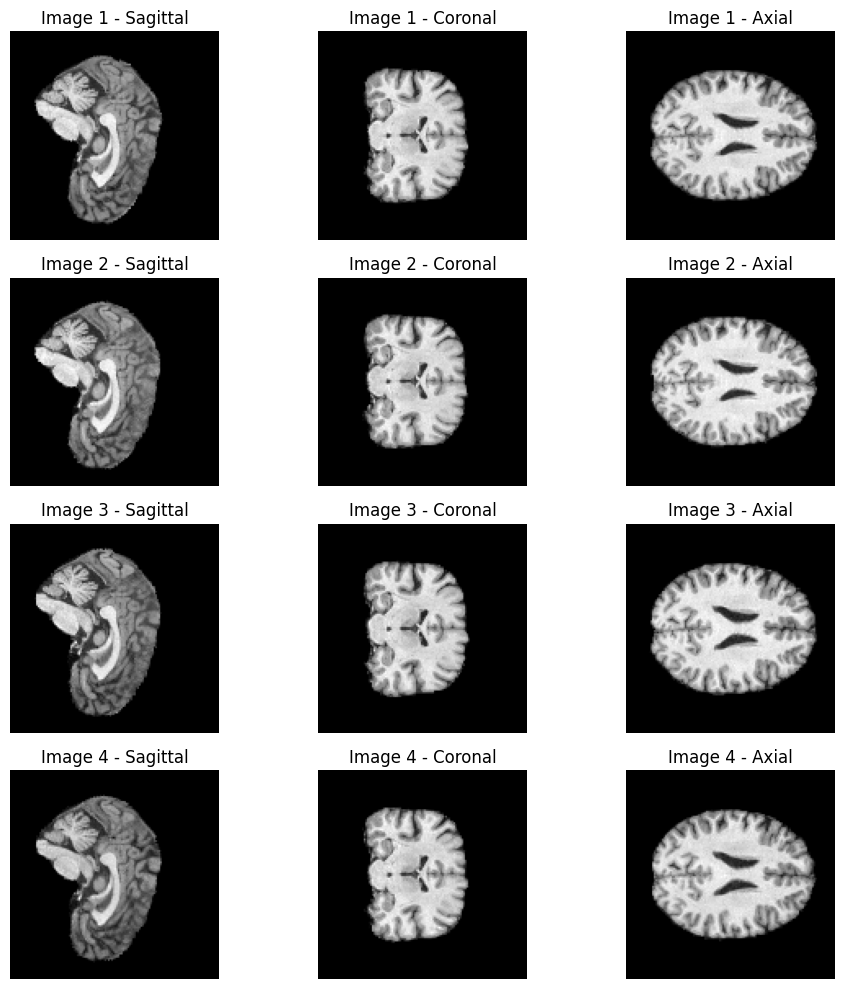

In [9]:
imd.show_first_4_nifti(oasis_t1_registered_folder)

### Dallas

In [ ]:
dallas_t1_unprocessed_folder = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_unprocessed_skullstrip/"

dallas_t1_final_output_folder_bias_corrected = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_bias_corrected/"

dallas_t1_final_output_folder_resampled = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_resampled/"

dallas_t1_final_output_folder_registered = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_registered/"



dallas_t1_final_output_folder_registered_final = ROOT_DIR+"datasets/final_t1_dataset_small/dallas_registered_final/"
os.makedirs(dallas_t1_final_output_folder_registered, exist_ok=True)
os.makedirs(dallas_t1_final_output_folder_registered_final, exist_ok=True)

In [ ]:
imd.show_first_4_nifti(dallas_t1_unprocessed_folder)

Apply bias field correction

In [ ]:


def apply_bias_correction(args):
    img_file, output_folder = args
    output_filepath = os.path.join(output_folder, os.path.basename(img_file))

    if not os.path.isfile(output_filepath):
        input_image = sitk.ReadImage(img_file, sitk.sitkFloat32)

        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        output_image = corrector.Execute(input_image)

        sitk.WriteImage(output_image, output_filepath)
        return f"Processed {os.path.basename(img_file)}"
    else:
        return f"Skipped {os.path.basename(img_file)}, already processed"

# Get all NIfTI files from the unprocessed folder
print("reading folder")
dallas_files = sorted(glob.glob(os.path.join(dallas_t1_unprocessed_folder, "*.nii*")))
print("finished reading folder")
tasks = [(img_file, dallas_t1_final_output_folder_registered) for img_file in dallas_files]

# Multiprocessing
with mp.Pool(processes=48) as pool:
    results = list(tqdm(pool.imap_unordered(apply_bias_correction, tasks), total=len(tasks)))


In [ ]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_registered)

Resample the images to 1mm3

In [ ]:
dprepro.resample_nifti_files_folder_multithreaded(
    dallas_t1_final_output_folder_bias_corrected,
    dallas_t1_final_output_folder_resampled,
    out_spacing=[1,1,1],
    max_workers=48)


In [ ]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_resampled)

In [ ]:
def reorient_to_ras(image_path):
    try:
        itk_image = sitk.ReadImage(image_path)
        oriented_image = sitk.DICOMOrient(itk_image, "RAS")
        sitk.WriteImage(oriented_image, image_path)
        return None
    except Exception as e:
        return (image_path, str(e))

image_paths = glob.glob(os.path.join(dallas_t1_final_output_folder_resampled, "*.nii.gz"))

with mp.Pool(processes=min(48, mp.cpu_count())) as pool:
    results = list(tqdm(pool.imap_unordered(reorient_to_ras, image_paths), total=len(image_paths)))

errors = [r for r in results if r is not None]
print(f"Done: {len(image_paths) - len(errors)}/{len(image_paths)}")
if errors:
    print("Errors:")
    for p, msg in errors[:10]:
        print(f"- {p}: {msg}")

In [ ]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_resampled)

In [ ]:

t1_template_path = ROOT_DIR + "datasets/mni_icbm152_nlin_sym_09a/template_t1_128.nii.gz"

In [ ]:
# images and masks
dprepro.register_nifti_files_folder_multithreaded(
    fixed_reference=t1_template_path,
    dataset_path=dallas_t1_final_output_folder_resampled,
    output_path = dallas_t1_final_output_folder_registered,
    register_masks=False,
    max_workers=96
)


In [ ]:
imd.show_first_4_nifti(dallas_t1_final_output_folder_registered)

In [ ]:
failed_t1_small_dallas = [16, 27, 62, 66, 79, 88, 162, 163, 243, 249, 260, 338, 358, 364, 470, 483, 592, 600, 708, 718, 731, 770, 797, 818, 834, 867, 887, 893, 944]

In [ ]:
# Get the list of files from the OASIS T1 dataset
dallas_files = os.listdir(dallas_t1_final_output_folder_registered)
failed_registration_final_t1_dataset_dallas_filenames = []

# Print the filenames corresponding to the failed registration indexes
print(f"Failed registration files in dallas T1 dataset ({len(failed_t1_small_dallas)} files):\n")
for idx in failed_t1_small_dallas:
    if idx < len(dallas_files):
        print(f"Index {idx}: {dallas_files[idx]}")
        failed_registration_final_t1_dataset_dallas_filenames.append(dallas_files[idx])
    else:
        print(f"Index {idx}: OUT OF RANGE (total files: {len(dallas_files)})")



In [ ]:
print(failed_registration_final_t1_dataset_dallas_filenames)